Date: July 20th, 2026 - July 23rd, 2026

Questions:

1. What's the distribution of HPD complaints across NYC boroughs, and does one borough clearly dominate?
2. Where are HPD complaints geographically concentrated, and what might that clustering reflect (e.g. housing age, density, building type)?
3. What are the most common HPD complaint types, and what does that ranking suggest about the state of NYC's housing stock?

In [1]:
import requests, pandas as pd
import matplotlib.pyplot as plt

url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"
params = {
    "$where": "agency='HPD' AND created_date > '2026-06-01T00:00:00'",
    "$limit": 5000,
    "$order": "created_date DESC"
}

resp = requests.get(url, params=params)
df = pd.DataFrame(resp.json())

In [2]:
df.head(20)

,unique_key,created_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,...,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,closed_date
0,69789953,2026-07-20T23:53:25.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11214,1975 83 STREET,...,BROOKLYN,985037,160336,PHONE,Unspecified,BROOKLYN,40.606761590216195,-73.99716568618568,"{'type': 'Point', 'coordinates': [-73.99716568...",NaN
1,69789940,2026-07-20T23:53:06.000,HPD,Department of Housing Preservation and Develop...,GENERAL,JANITOR/SUPER,NO JANITOR AVAILABLE,RESIDENTIAL BUILDING,10001,266 WEST 25 STREET,...,MANHATTAN,985225,211108,ONLINE,Unspecified,MANHATTAN,40.74611922267119,-73.99648127510599,"{'type': 'Point', 'coordinates': [-73.99648127...",NaN
2,69783644,2026-07-20T23:47:30.000,HPD,Department of Housing Preservation and Develop...,PAINT/PLASTER,WALL,BULGING/HOLE/CRACKED,RESIDENTIAL BUILDING,10460,1016 EAST 174 STREET,...,BRONX,1016452,243860,PHONE,Unspecified,BRONX,40.8359559809235,-73.88362767691928,"{'type': 'Point', 'coordinates': [-73.88362767...",NaN
3,69782158,2026-07-20T23:47:30.000,HPD,Department of Housing Preservation and Develop...,UNSANITARY CONDITION,PESTS,ROACHES,RESIDENTIAL BUILDING,10460,1016 EAST 174 STREET,...,BRONX,1016452,243860,PHONE,Unspecified,BRONX,40.8359559809235,-73.88362767691928,"{'type': 'Point', 'coordinates': [-73.88362767...",NaN
4,69779059,2026-07-20T23:47:30.000,HPD,Department of Housing Preservation and Develop...,UNSANITARY CONDITION,PESTS,MICE,RESIDENTIAL BUILDING,10460,1016 EAST 174 STREET,...,BRONX,1016452,243860,PHONE,Unspecified,BRONX,40.8359559809235,-73.88362767691928,"{'type': 'Point', 'coordinates': [-73.88362767...",NaN
5,69778972,2026-07-20T23:47:30.000,HPD,Department of Housing Preservation and Develop...,PAINT/PLASTER,CEILING,CHIPPED/PEELING/FLAKING,RESIDENTIAL BUILDING,10460,1016 EAST 174 STREET,...,BRONX,1016452,243860,PHONE,Unspecified,BRONX,40.8359559809235,-73.88362767691928,"{'type': 'Point', 'coordinates': [-73.88362767...",NaN
6,69779108,2026-07-20T23:32:00.000,HPD,Department of Housing Preservation and Develop...,WATER LEAK,HEAVY FLOW,AT WALL OR CEILING,RESIDENTIAL BUILDING,11434,167-11 144 DRIVE,...,QUEENS,1046493,181643,PHONE,Unspecified,QUEENS,40.665026015854224,-73.77564106079835,"{'type': 'Point', 'coordinates': [-73.77564106...",NaN
7,69790043,2026-07-20T23:30:20.000,HPD,Department of Housing Preservation and Develop...,UNSANITARY CONDITION,GARBAGE/RECYCLING STORAGE,ACCUMULATION,RESIDENTIAL BUILDING,11377,72-10 41 AVENUE,...,QUEENS,1013908,210718,ONLINE,Unspecified,QUEENS,40.74499909172425,-73.89296757512533,"{'type': 'Point', 'coordinates': [-73.89296757...",NaN
8,69788292,2026-07-20T23:30:20.000,HPD,Department of Housing Preservation and Develop...,DOOR/WINDOW,DOOR,NEEDS KEY FOR EXIT,RESIDENTIAL BUILDING,11377,72-10 41 AVENUE,...,QUEENS,1013908,210718,ONLINE,Unspecified,QUEENS,40.74499909172425,-73.89296757512533,"{'type': 'Point', 'coordinates': [-73.89296757...",NaN
9,69785258,2026-07-20T23:26:46.000,HPD,Department of Housing Preservation and Develop...,UNSANITARY CONDITION,GARBAGE/RECYCLING STORAGE,MISSING OR INADEQUATE CANS/LID,RESIDENTIAL BUILDING,11377,72-10 41 AVENUE,...,QUEENS,1013908,210718,ONLINE,Unspecified,QUEENS,40.74499909172425,-73.89296757512533,"{'type': 'Point', 'coordinates': [-73.89296757...",NaN


In [3]:
borough_counts = df['borough'].value_counts()
print(borough_counts)
print(borough_counts.index)

borough
BROOKLYN         1407
BRONX            1365
MANHATTAN        1288
QUEENS            868
STATEN ISLAND      72
Name: count, dtype: int64
Index(['BROOKLYN', 'BRONX', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND'], dtype='object', name='borough')


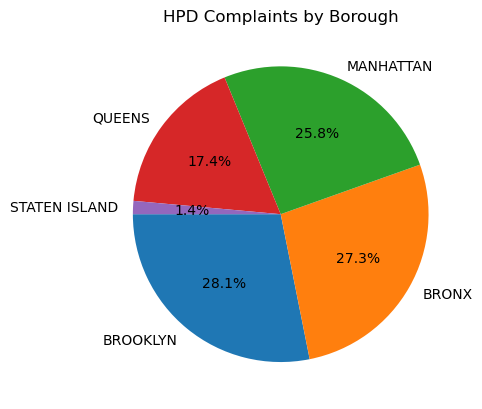

In [4]:
fig, ax = plt.subplots()
ax.pie(borough_counts, labels=borough_counts.index, autopct='%1.1f%%', startangle=180)
ax.set_title('HPD Complaints by Borough')
plt.show()

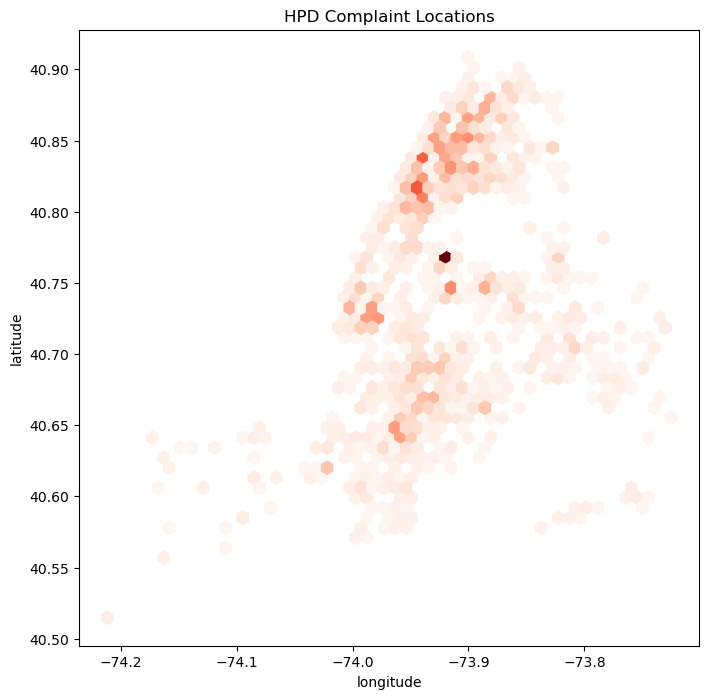

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

#convert value from object to numeric, errors coerce turns values in NaN so it doesn't crash
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

#drop na values
df_plot = df.dropna(subset=['latitude', 'longitude'])

df_plot = df_plot[(df_plot['latitude'].between(40.4, 40.95)) & (df_plot['longitude'].between(-74.3, -73.65))]

ax.hexbin(df_plot['longitude'], df_plot['latitude'], gridsize=50, cmap='Reds', mincnt=1)
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
ax.set_title('HPD Complaint Locations')
plt.show()

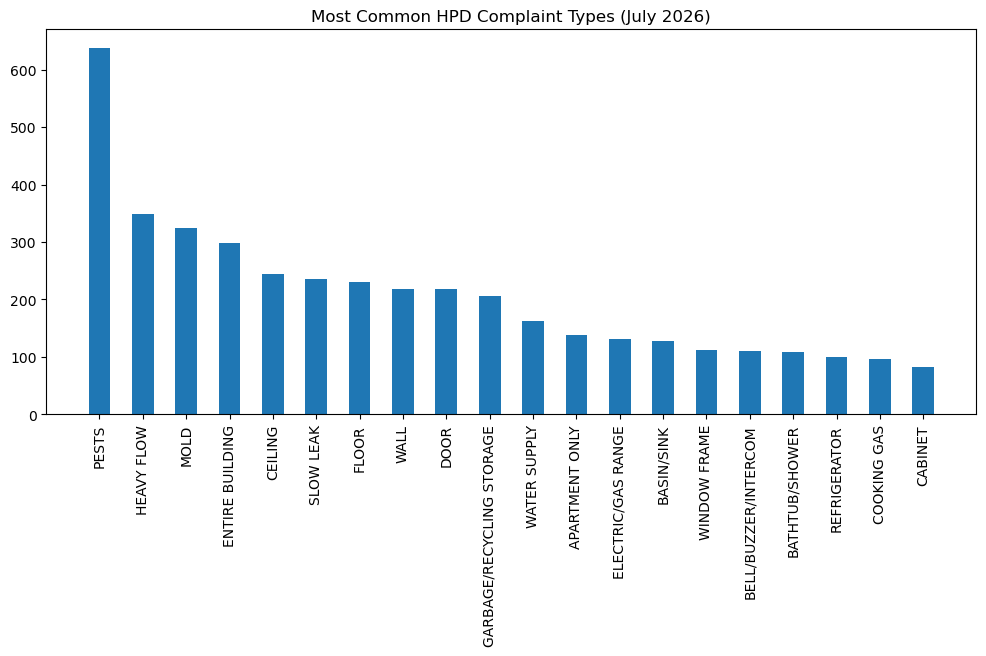

In [6]:
descriptor_counts = df['descriptor'].value_counts().head(20)
plt.figure(figsize=(12,5))
plt.bar(descriptor_counts.index, descriptor_counts, width = 0.5)
plt.xticks(rotation=90)
plt.title('Most Common HPD Complaint Types (July 2026)')
#plt.tight_layout()
plt.show()

#print(descriptor_counts)